In [16]:
import pandas as pd
import os
import json
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
def load_all_jsonls(results_dir):
    dfs = []
    for fname in glob(os.path.join(results_dir, "*.jsonl")):
        with open(fname, "r", encoding="utf-8") as fin:
            rows = [json.loads(line) for line in fin]
        dfs.append(pd.DataFrame(rows))
    return pd.concat(dfs, ignore_index=True)

## Full

In [28]:
RESULTS_DIR = "results/results_fictionqa_full/"

df = load_all_jsonls(RESULTS_DIR)

print(f"Loaded {len(df)} rows from {RESULTS_DIR}")
# display(df.head())

Loaded 158 rows from results/results_fictionqa_full/


In [29]:
def compute_overall_metrics(df):
    total = len(df)
    correct = (df['verdict'] == 'CORRECT').sum()
    incorrect = (df['verdict'] == 'INCORRECT').sum()
    accuracy = correct / total if total else float("nan")
    print(f"Total: {total}")
    print(f"Correct: {correct} ({accuracy:.2%})")
    print(f"Incorrect: {incorrect} ({incorrect/total:.2%})")
    return {"total": total, "correct": correct, "incorrect": incorrect, "accuracy": accuracy}

metrics = compute_overall_metrics(df)

Total: 158
Correct: 88 (55.70%)
Incorrect: 62 (39.24%)


In [30]:
# Fraction of not possible per style
not_possible_stats = (
    df.groupby("style")
      .apply(lambda g: (g["possible"] == False).mean())
      .reset_index(name="frac_not_possible")
      .sort_values("frac_not_possible", ascending=False)
)

print("Per-style fraction of NOT possible cases:")
display(not_possible_stats)


Per-style fraction of NOT possible cases:


/var/folders/jc/30r_j3x926dc7m5334ltq4880000gn/T/ipykernel_94595/3673127948.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["possible"] == False).mean())


,style,frac_not_possible
1,_style_corporate_num_000,0.500000
2,_style_social_num_000,0.269231
0,_style_blog_num_000,0.055556


In [31]:
def accuracy_on_possible(group):
    possible = group[group["possible"] == True]
    if len(possible) == 0:
        return float('nan')
    return (possible["verdict"] == "CORRECT").mean()

possible_accuracy_stats = (
    df.groupby("style")
      .apply(accuracy_on_possible)
      .reset_index(name="accuracy_possible_true")
      .sort_values("accuracy_possible_true", ascending=False)
)

print("Per-style accuracy (only when possible==True):")
display(possible_accuracy_stats)


Per-style accuracy (only when possible==True):


/var/folders/jc/30r_j3x926dc7m5334ltq4880000gn/T/ipykernel_94595/2656887521.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(accuracy_on_possible)


,style,accuracy_possible_true
0,_style_blog_num_000,0.723404
2,_style_social_num_000,0.638889
1,_style_corporate_num_000,0.583333


In [32]:
accuracies = list(possible_accuracy_stats.to_dict()["accuracy_possible_true"].values())
ac_mean = sum(accuracies) / len(accuracies)
ac_std = (sum((x - ac_mean) ** 2 for x in accuracies) / len(accuracies)) ** 0.5
print(f"Mean accuracy on possible cases: {ac_mean:.2%} (std: {ac_std:.2%})")

Mean accuracy on possible cases: 64.85% (std: 5.76%)


In [33]:
# Filter to only possible==True
df_possible = df[df["possible"] == True]
overall_possible_accuracy = (df_possible["verdict"] == "CORRECT").mean()

print(len(df_possible), "rows with possible == True")
print(f"Overall accuracy (possible == True): {overall_possible_accuracy:.2%}")

107 rows with possible == True
Overall accuracy (possible == True): 66.36%


In [34]:
def group_accuracy(df, by='style'):
    df = df[df["possible"] == True]
    stats = df.groupby(by)['verdict'].apply(lambda x: (x == "CORRECT").mean())
    return stats.reset_index(name='accuracy').sort_values('accuracy', ascending=False)

df_style_acc = group_accuracy(df, by="style")
print("Per-style accuracy:")
display(df_style_acc)

df_event_acc = group_accuracy(df, by="event_id")
print("Per-event accuracy:")
display(df_event_acc)

Per-style accuracy:


,style,accuracy
0,_style_blog_num_000,0.723404
2,_style_social_num_000,0.638889
1,_style_corporate_num_000,0.583333


Per-event accuracy:


,event_id,accuracy
7,event_037,0.875000
9,event_039,0.857143
6,event_036,0.846154
8,event_038,0.846154
2,event_032,0.666667
3,event_033,0.666667
5,event_035,0.583333
1,event_031,0.555556
4,event_034,0.538462
0,event_030,0.272727


In [23]:
def show_sample_errors(df, group_by=None, n=5):
    errors = df[df['verdict'] != 'CORRECT']
    if group_by:
        errors = errors[errors[group_by] == group_by]
    if len(errors) > 0:
        display(errors.sample(min(n, len(errors))))
    else:
        print("No errors found.")

print("Sample errors:")
show_sample_errors(df, n=1)

Sample errors:


,identifier,event_id,style,run_id,fiction_id,question,correct_answer,prediction,possible,verdict,explanation
512,fictionqa_run1_1/_style_social_num_000/event_011,event_011,_style_social_num_000,fictionqa_run1_1,event_011_style_social_num_000,What caused the Unbiased Curriculum Experiment...,septicaemia outbreak,The Unbiased Curriculum Experiment from 1945 w...,True,INCORRECT,INCORRECT (the test answer provides detailed p...


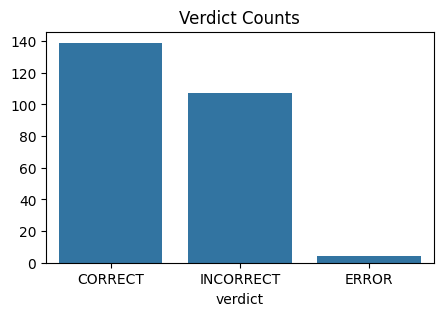

Accuracy when answer is possible: 57.87%
Accuracy when answer is NOT possible: 48.84%


In [10]:
if "verdict" in df.columns:
    verdict_counts = df['verdict'].value_counts()
    plt.figure(figsize=(5,3))
    sns.barplot(x=verdict_counts.index, y=verdict_counts.values)
    plt.title("Verdict Counts")
    plt.show()

if "possible" in df.columns:
    possible_acc = df[df['possible'] == True]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is possible: {possible_acc:.2%}")
    impossible_acc = df[df['possible'] == False]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is NOT possible: {impossible_acc:.2%}")
